In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# LOAD DATA
# ============================================================

csv_path = "/home/mapa/Documents/Tec/NextGenS/FacesDetection/CV-FaceMorphs-master/dev/FaceMorphing/ControlledMorphGeneration/MorphGeneration_Pipeline_DistributionalSimilarity/TrustRegions/results/cluster_quality_summary.csv"

df = pd.read_csv(csv_path)

print("\n[Cluster Quality Summary]")
print(df)



[Cluster Quality Summary]
    cluster_id  n_samples  original_n  clean_n  clean_retention_rate  \
0          393        918        1561      918              0.588085   
1           92       1186        1310     1186              0.905344   
2          118        717         973      717              0.736896   
3           40        835         967      835              0.863495   
4          280        405         926      405              0.437365   
5          133        537         910      537              0.590110   
6          194        182         696      182              0.261494   
7          129        254         495      254              0.513131   
8          340        316         396      316              0.797980   
9          277        178         245      178              0.726531   
10         423        166         210      166              0.790476   
11         311        111         203      111              0.546798   
12         513         39         173

In [4]:

print("\n[Dataset information]")
print(df.info())

print("\n[Descriptive statistics]")
print(df.describe())



[Dataset information]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cluster_id                   15 non-null     int64  
 1   n_samples                    15 non-null     int64  
 2   original_n                   15 non-null     int64  
 3   clean_n                      15 non-null     int64  
 4   clean_retention_rate         15 non-null     float64
 5   compression_mean_radius      15 non-null     float64
 6   compression_std_radius       15 non-null     float64
 7   compression_median_radius    15 non-null     float64
 8   compression_q90_radius       15 non-null     float64
 9   density_mean_knn_distance    15 non-null     float64
 10  density_median_knn_distance  15 non-null     float64
 11  density_knn                  15 non-null     float64
 12  fitted_distribution          15 non-null     object 
 13 

In [5]:

# Order clusters according to their original population
df = df.sort_values(
    by="original_n",
    ascending=False
).reset_index(drop=True)

# Create a categorical label for plots
df["cluster_label"] = "Cluster " + df["cluster_id"].astype(str)


display_columns = [
    "cluster_id",
    "original_n",
    "clean_n",
    "clean_retention_rate",

    "compression_mean_radius",
    "compression_std_radius",
    "compression_median_radius",
    "compression_q90_radius",

    "density_mean_knn_distance",
    "density_median_knn_distance",
    "density_knn",

    "fitted_distribution",
    "ks",
    "aic",

    "bootstrap_model_stability"
]

summary_table = df[display_columns].copy()

# Format percentages
summary_table["clean_retention_rate"] *= 100
summary_table["bootstrap_model_stability"] *= 100

print("\n[Cluster Quality Metrics Table]")
print(summary_table.to_string(index=False))


[Cluster Quality Metrics Table]
 cluster_id  original_n  clean_n  clean_retention_rate  compression_mean_radius  compression_std_radius  compression_median_radius  compression_q90_radius  density_mean_knn_distance  density_median_knn_distance  density_knn fitted_distribution       ks          aic  bootstrap_model_stability
        393        1561      918             58.808456                16.832073                1.879307                  16.816939               19.212451                   0.230415                     0.187387     4.339998               Gamma 0.027852  -989.667357                       45.0
         92        1310     1186             90.534351                16.858506                1.814228                  16.749597               19.159215                   0.204101                     0.167692     4.899531             Weibull 0.016920 -1535.774965                       84.0
        118         973      717             73.689620                15.053974         

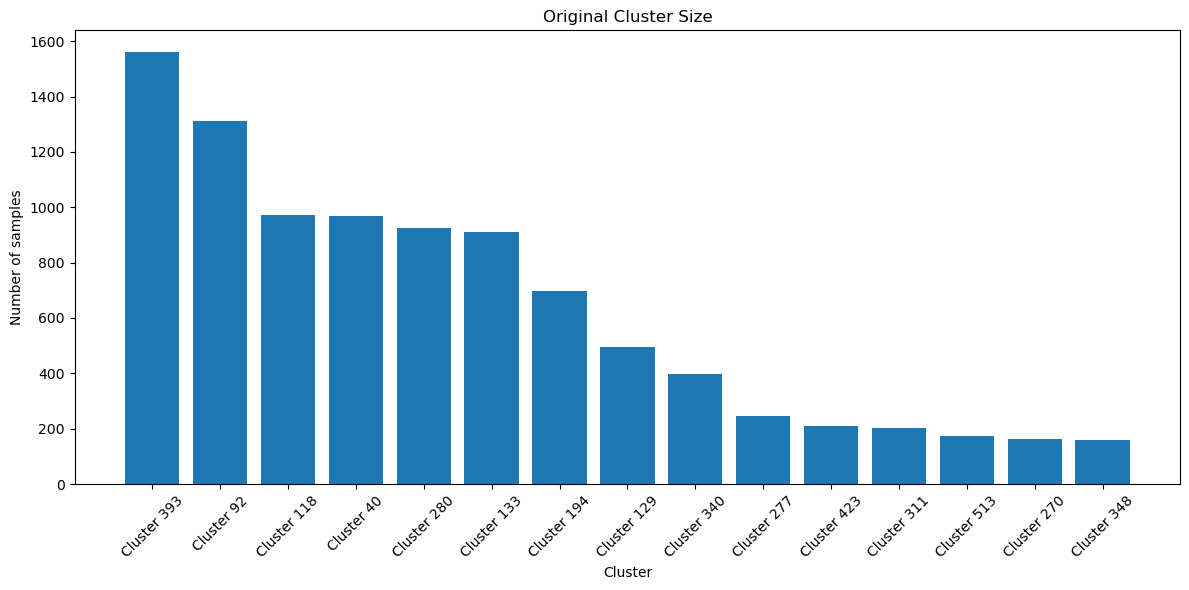

In [6]:
# ============================================================
# 1. CLUSTER SIZE
# ============================================================

plt.figure(figsize=(12, 6))

plt.bar(
    df["cluster_label"],
    df["original_n"]
)

plt.xticks(rotation=45)
plt.xlabel("Cluster")
plt.ylabel("Number of samples")
plt.title("Original Cluster Size")

plt.tight_layout()
plt.show()

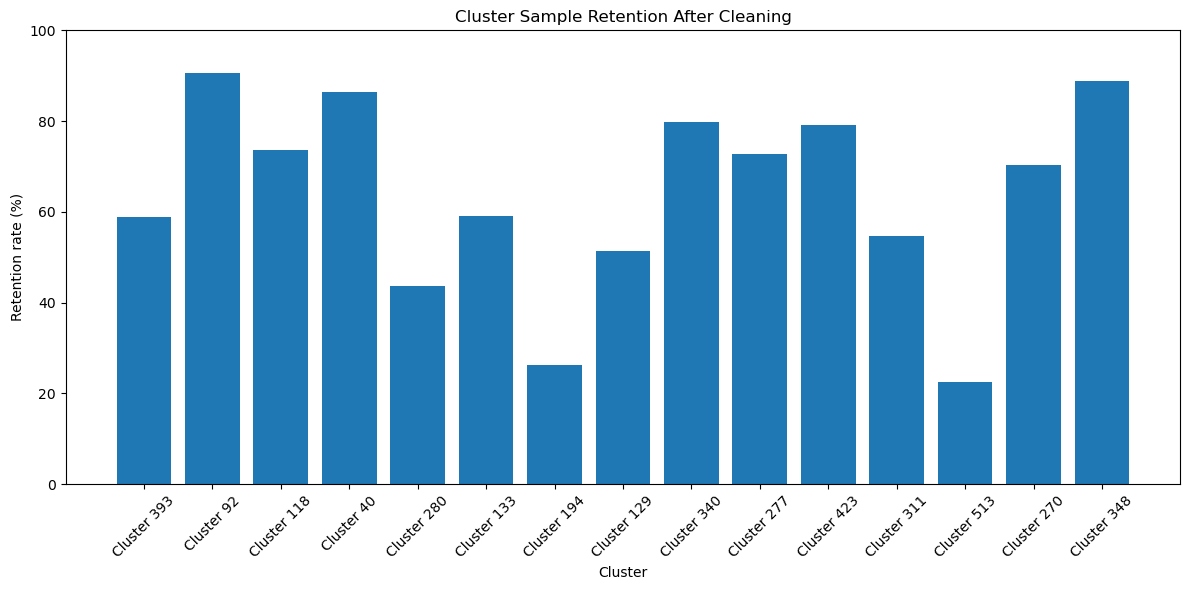

In [7]:
# ============================================================
# 2. CLEANING RETENTION
# ============================================================

plt.figure(figsize=(12, 6))

plt.bar(
    df["cluster_label"],
    df["clean_retention_rate"] * 100
)

plt.xticks(rotation=45)
plt.xlabel("Cluster")
plt.ylabel("Retention rate (%)")
plt.title("Cluster Sample Retention After Cleaning")

plt.ylim(0, 100)

plt.tight_layout()
plt.show()


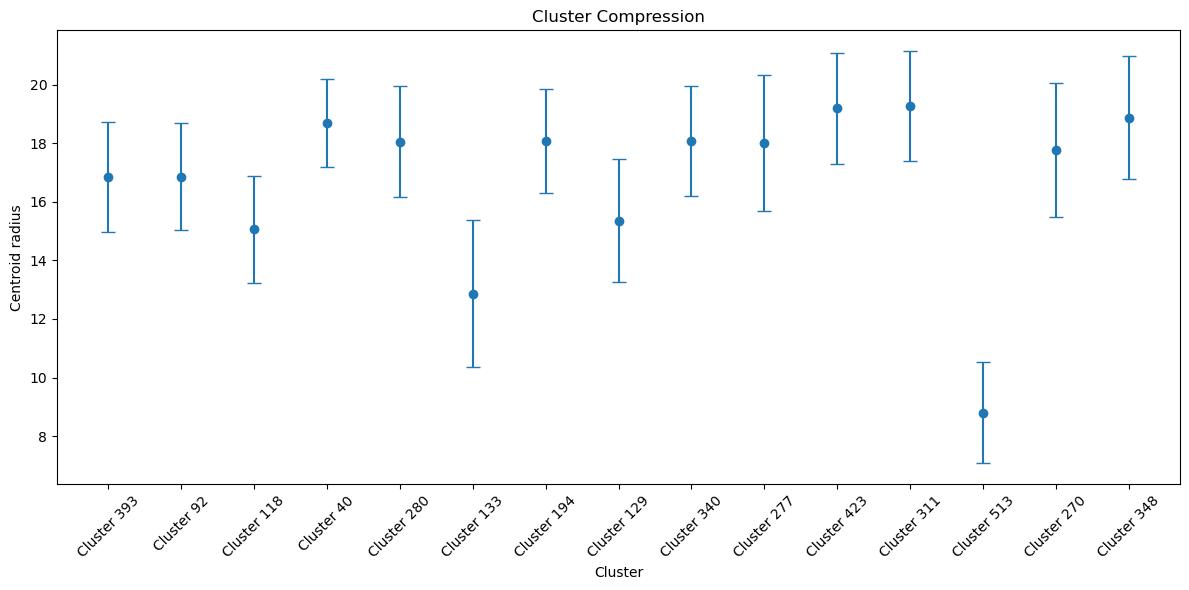

In [8]:
# ============================================================
# 3. COMPRESSION
# ============================================================

plt.figure(figsize=(12, 6))

plt.errorbar(
    df["cluster_label"],
    df["compression_mean_radius"],
    yerr=df["compression_std_radius"],
    fmt="o",
    capsize=5
)

plt.xticks(rotation=45)
plt.xlabel("Cluster")
plt.ylabel("Centroid radius")
plt.title("Cluster Compression")

plt.tight_layout()
plt.show()

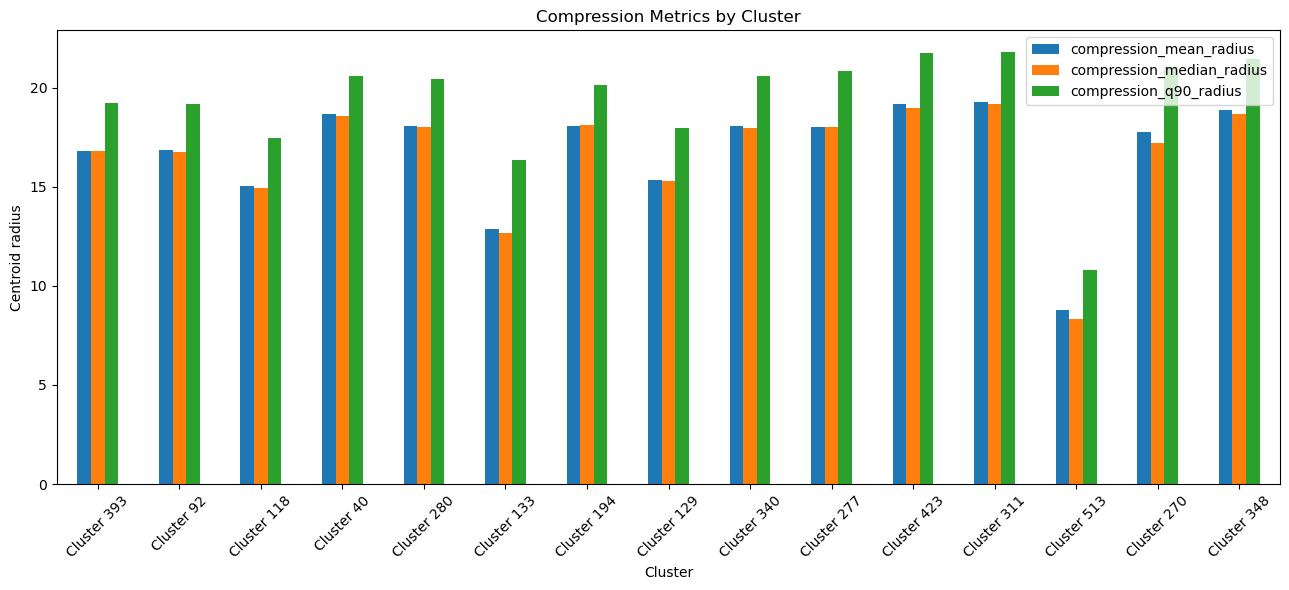

In [9]:
# ============================================================
# 4. COMPRESSION STATISTICS
# ============================================================

compression_columns = [
    "compression_mean_radius",
    "compression_median_radius",
    "compression_q90_radius"
]

compression_plot = df[
    ["cluster_label"] + compression_columns
].set_index("cluster_label")

compression_plot.plot(
    kind="bar",
    figsize=(13, 6)
)

plt.xlabel("Cluster")
plt.ylabel("Centroid radius")
plt.title("Compression Metrics by Cluster")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

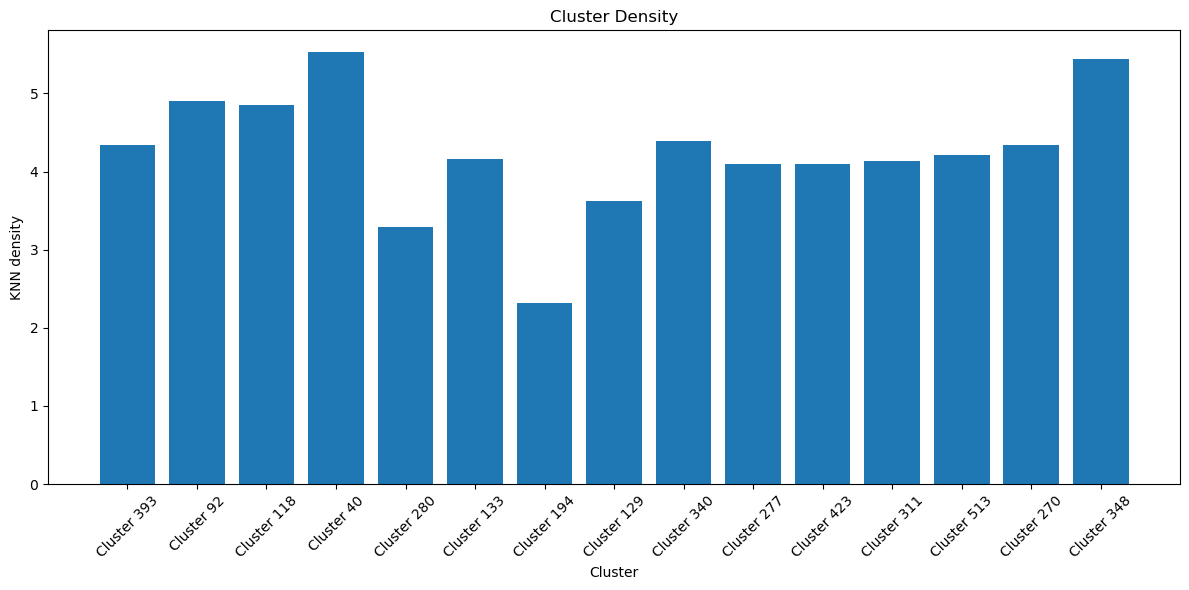

In [10]:
# ============================================================
# 5. DENSITY
# ============================================================

plt.figure(figsize=(12, 6))

plt.bar(
    df["cluster_label"],
    df["density_knn"]
)

plt.xticks(rotation=45)
plt.xlabel("Cluster")
plt.ylabel("KNN density")
plt.title("Cluster Density")

plt.tight_layout()
plt.show()

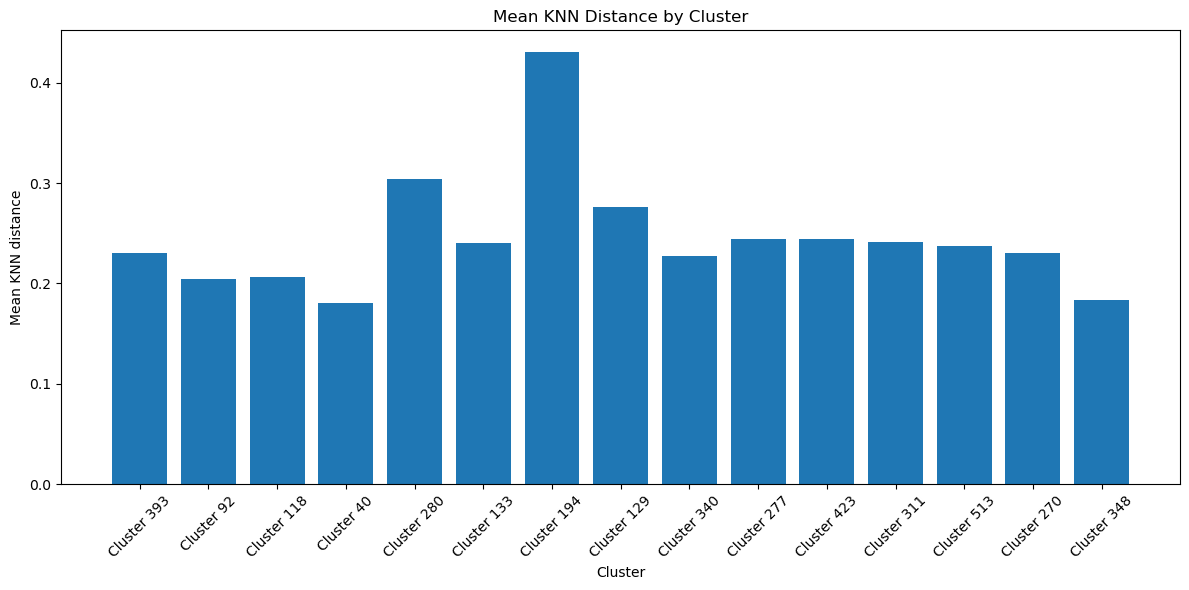

In [11]:
# ============================================================
# 6. MEAN KNN DISTANCE
# ============================================================

plt.figure(figsize=(12, 6))

plt.bar(
    df["cluster_label"],
    df["density_mean_knn_distance"]
)

plt.xticks(rotation=45)
plt.xlabel("Cluster")
plt.ylabel("Mean KNN distance")
plt.title("Mean KNN Distance by Cluster")

plt.tight_layout()
plt.show()

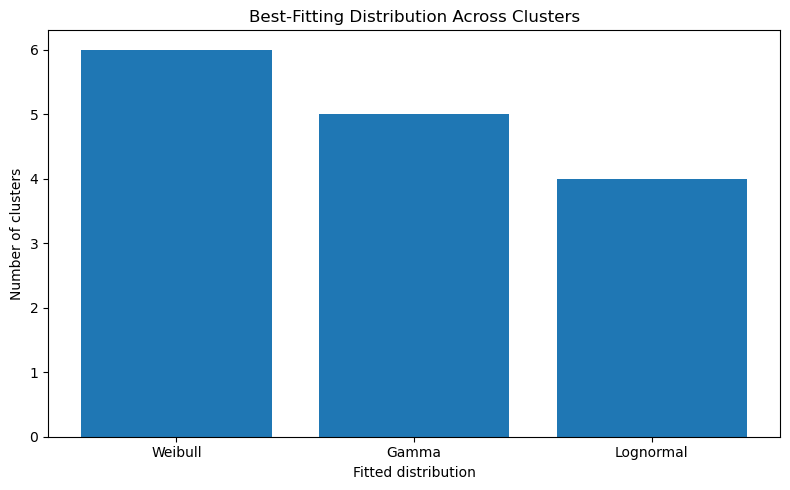

In [12]:

# ============================================================
# 7. DISTRIBUTION MODEL
# ============================================================

distribution_counts = (
    df["fitted_distribution"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

plt.bar(
    distribution_counts.index,
    distribution_counts.values
)

plt.xlabel("Fitted distribution")
plt.ylabel("Number of clusters")
plt.title("Best-Fitting Distribution Across Clusters")

plt.tight_layout()
plt.show()

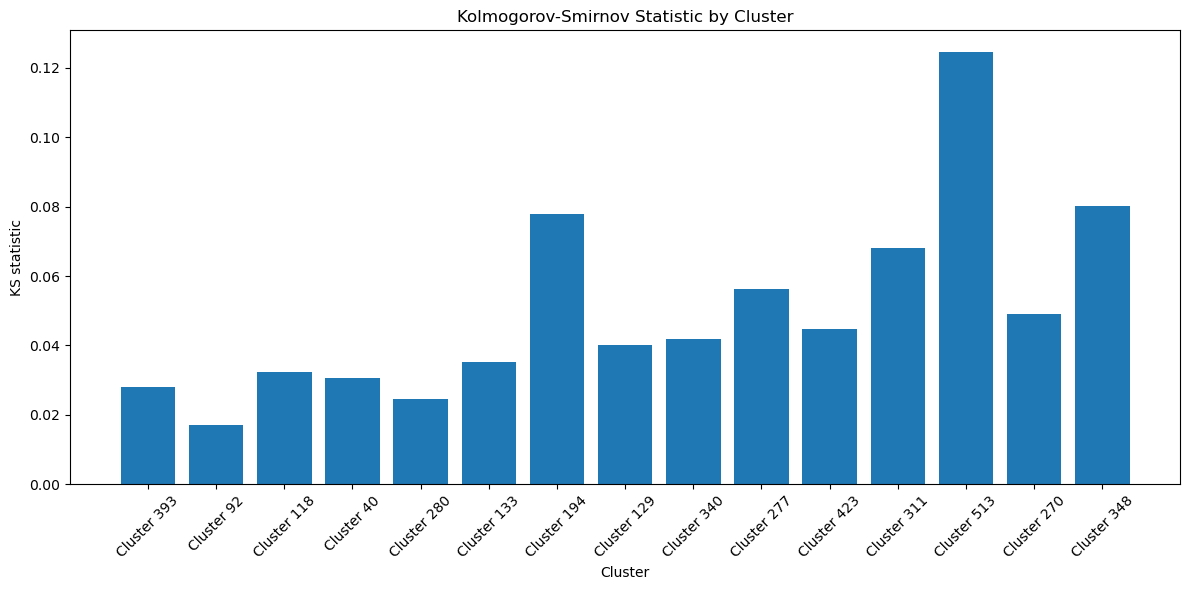

In [13]:
# ============================================================
# 8. KS STATISTIC
# ============================================================

plt.figure(figsize=(12, 6))

plt.bar(
    df["cluster_label"],
    df["ks"]
)

plt.xticks(rotation=45)
plt.xlabel("Cluster")
plt.ylabel("KS statistic")
plt.title("Kolmogorov-Smirnov Statistic by Cluster")

plt.tight_layout()
plt.show()

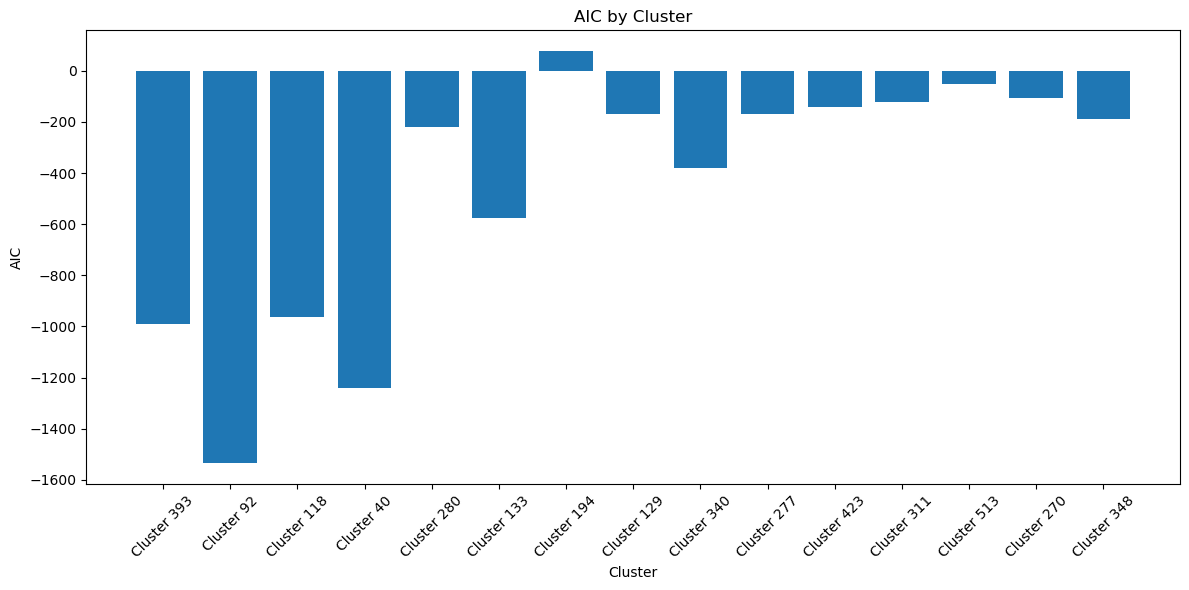

In [14]:
# ============================================================
# 9. AIC
# ============================================================

plt.figure(figsize=(12, 6))

plt.bar(
    df["cluster_label"],
    df["aic"]
)

plt.xticks(rotation=45)
plt.xlabel("Cluster")
plt.ylabel("AIC")
plt.title("AIC by Cluster")

plt.tight_layout()
plt.show()

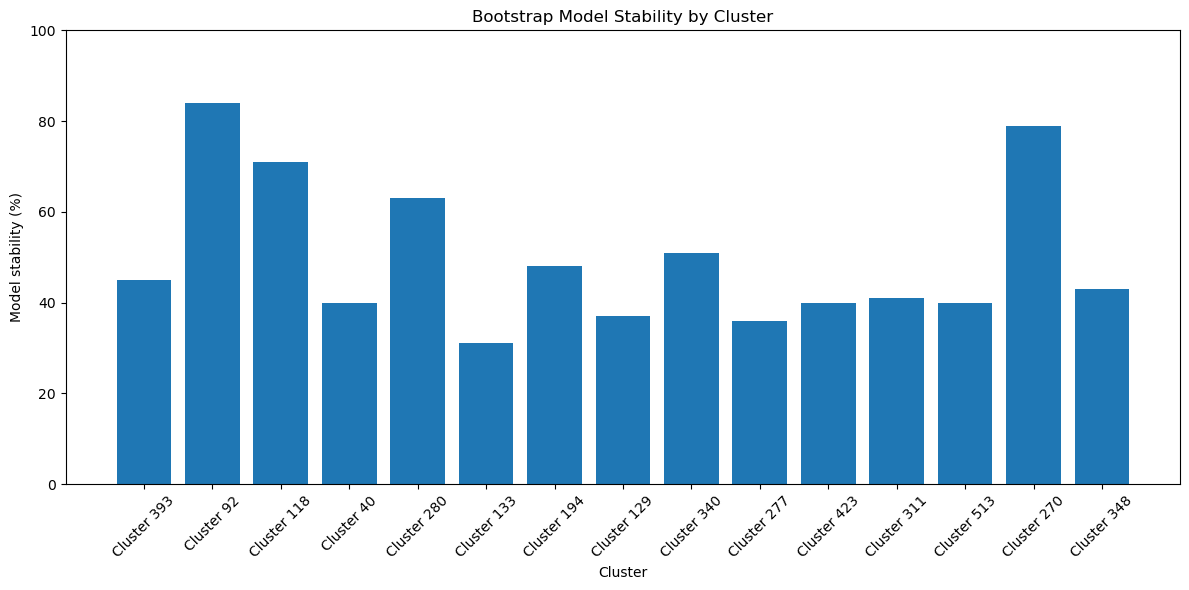

In [15]:
# ============================================================
# 10. BOOTSTRAP MODEL STABILITY
# ============================================================

plt.figure(figsize=(12, 6))

plt.bar(
    df["cluster_label"],
    df["bootstrap_model_stability"] * 100
)

plt.xticks(rotation=45)
plt.xlabel("Cluster")
plt.ylabel("Model stability (%)")
plt.title("Bootstrap Model Stability by Cluster")

plt.ylim(0, 100)

plt.tight_layout()
plt.show()